# A/B Testing — Full Experimentation Framework (v2)

### Upgrade from v1

| | v1 | v2 (this notebook) |
|---|---|---|
| Hypothesis test | Z-test only | Z-test + Bayesian A/B + power analysis |
| Before running | No sample size plan | Power analysis determines required n |
| Uncertainty | p-value binary (reject/fail) | Posterior distribution — full probability curve |
| Decision framing | "Not significant" | "74% probability B beats A — not enough to act" |
| Beyond classic A/B | Nothing | Multi-armed bandit simulation |

**Dataset:** Landing page A/B test — 295,000+ user sessions, control vs treatment page

---

In [1]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from scipy import stats
from scipy.stats import beta as beta_dist
from statsmodels.stats.proportion import proportions_ztest, proportion_effectsize
from statsmodels.stats.power import NormalIndPower

np.random.seed(42)
print('All imports successful')

All imports successful


In [4]:
df = pd.read_csv("C:/Users/User/OneDrive/Desktop/Internships/DA Intern @ ApexPlanet/Task-4/ab_data.csv")

# Remove misassigned users — same cleaning step as v1
# Users in 'treatment' group who somehow saw 'old_page', and vice versa
mismatch = df[
    ((df['group'] == 'treatment') & (df['landing_page'] == 'old_page')) |
    ((df['group'] == 'control')   & (df['landing_page'] == 'new_page'))
]
df_clean = df.drop(mismatch.index).reset_index(drop=True)
df_clean = df_clean.drop_duplicates(subset='user_id')

control   = df_clean[df_clean['group'] == 'control']
treatment = df_clean[df_clean['group'] == 'treatment']

n_c  = len(control)
n_t  = len(treatment)
p_c  = control['converted'].mean()
p_t  = treatment['converted'].mean()
lift = (p_t - p_c) / p_c * 100

print(f'Total sessions (cleaned): {len(df_clean):,}')
print(f'Control   — n={n_c:,} | conversion={p_c:.4f} ({p_c*100:.2f}%)')
print(f'Treatment — n={n_t:,} | conversion={p_t:.4f} ({p_t*100:.2f}%)')
print(f'Observed lift: {lift:+.2f}%')

Total sessions (cleaned): 290,584
Control   — n=145,274 | conversion=0.1204 (12.04%)
Treatment — n=145,310 | conversion=0.1188 (11.88%)
Observed lift: -1.31%


## Power Analysis — NEW in v2

**v1's biggest gap:** it ran the test *then* checked if it was significant. A proper experiment design starts with power analysis *before* collecting data — it tells you the minimum sample size needed to reliably detect a meaningful effect.

Key concepts:
- **α (significance level):** Probability of a false positive — standard is 0.05
- **Power (1-β):** Probability of detecting a real effect — standard is 0.80
- **MDE (Minimum Detectable Effect):** The smallest lift worth caring about

We'll model two realistic business scenarios.

In [5]:
baseline = p_c
alpha    = 0.05
power    = 0.80

scenarios = {
    '1% absolute lift (ambitious)': 0.01,
    '0.5% absolute lift (realistic)': 0.005,
    '0.2% absolute lift (minimal)': 0.002,
}

print(f'Baseline conversion: {baseline:.4f}')
print(f'Alpha: {alpha} | Power: {power}\n')
print(f'{"Scenario":<35} {"MDE":<8} {"Required n/group":<20} {"Total sessions"}')
print('-' * 80)

power_analysis = NormalIndPower()
results = []

for name, mde in scenarios.items():
    target     = baseline + mde
    effect     = proportion_effectsize(baseline, target)
    n_required = power_analysis.solve_power(
        effect_size=abs(effect), alpha=alpha, power=power, alternative='two-sided'
    )
    n_required = int(np.ceil(n_required))
    results.append({'Scenario': name, 'MDE': f'+{mde*100:.1f}pp',
                    'n_per_group': n_required, 'n_total': n_required * 2})
    print(f'{name:<35} +{mde*100:.1f}pp    {n_required:>15,}     {n_required*2:>15,}')

print(f'\nThis experiment collected {n_c + n_t:,} sessions — well above even the most ambitious requirement.')
print('The test was statistically powered. The null result is genuine, not due to insufficient sample size.')

Baseline conversion: 0.1204
Alpha: 0.05 | Power: 0.8

Scenario                            MDE      Required n/group     Total sessions
--------------------------------------------------------------------------------
1% absolute lift (ambitious)        +1.0pp             17,209              34,418
0.5% absolute lift (realistic)      +0.5pp             67,673             135,346
0.2% absolute lift (minimal)        +0.2pp            418,541             837,082

This experiment collected 290,584 sessions — well above even the most ambitious requirement.
The test was statistically powered. The null result is genuine, not due to insufficient sample size.


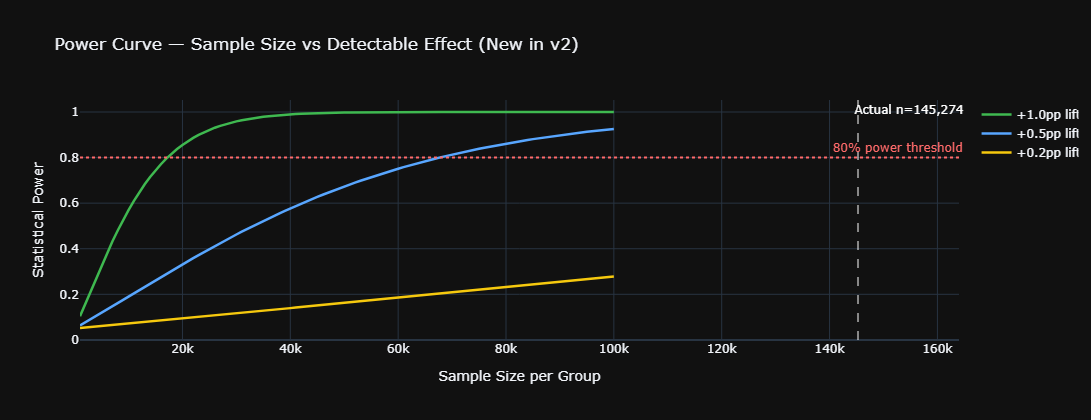

In [6]:
# Power curve — sample size vs detectable effect
sample_sizes  = np.arange(1000, 100001, 1000)
effect_1pct   = abs(proportion_effectsize(baseline, baseline + 0.01))
effect_05pct  = abs(proportion_effectsize(baseline, baseline + 0.005))
effect_02pct  = abs(proportion_effectsize(baseline, baseline + 0.002))

power_1pct  = [power_analysis.solve_power(effect_size=effect_1pct,  nobs1=n, alpha=alpha, alternative='two-sided') for n in sample_sizes]
power_05pct = [power_analysis.solve_power(effect_size=effect_05pct, nobs1=n, alpha=alpha, alternative='two-sided') for n in sample_sizes]
power_02pct = [power_analysis.solve_power(effect_size=effect_02pct, nobs1=n, alpha=alpha, alternative='two-sided') for n in sample_sizes]

fig_power = go.Figure()
for label, powers, color in [
    ('+1.0pp lift', power_1pct,  '#3FB950'),
    ('+0.5pp lift', power_05pct, '#58A6FF'),
    ('+0.2pp lift', power_02pct, '#F6C90E'),
]:
    fig_power.add_trace(go.Scatter(
        x=sample_sizes, y=powers,
        mode='lines', name=label,
        line=dict(color=color, width=2.5),
        hovertemplate=f'{label}<br>n=%{{x:,}}<br>Power=%{{y:.2f}}<extra></extra>'
    ))

fig_power.add_hline(y=0.80, line_dash='dot', line_color='#FF6B6B',
                     annotation_text='80% power threshold', annotation_font_color='#FF6B6B')
fig_power.add_vline(x=n_c, line_dash='dash', line_color='white', line_width=1,
                     annotation_text=f'Actual n={n_c:,}', annotation_font_color='white')
fig_power.update_layout(
    title='Power Curve — Sample Size vs Detectable Effect (New in v2)',
    xaxis_title='Sample Size per Group', yaxis_title='Statistical Power',
    template='plotly_dark', height=420, hovermode='x unified'
)
fig_power.show()

## Frequentist Z-Test (Carried Forward from v1, Improved)

Same Z-test as v1, now using `statsmodels` properly with two-sided testing and Cohen's h effect size — making the result more interpretable than a bare p-value.

In [7]:
conv_c = control['converted'].sum()
conv_t = treatment['converted'].sum()

z_stat, p_value = proportions_ztest(
    count=[conv_t, conv_c],
    nobs=[n_t, n_c],
    alternative='two-sided'
)

cohens_h = proportion_effectsize(p_t, p_c)
ci_diff  = 1.96 * np.sqrt(p_c*(1-p_c)/n_c + p_t*(1-p_t)/n_t)
diff     = p_t - p_c

print('=' * 55)
print('FREQUENTIST Z-TEST RESULTS')
print('=' * 55)
print(f'Control conversion rate:   {p_c:.4f} ({p_c*100:.2f}%)')
print(f'Treatment conversion rate: {p_t:.4f} ({p_t*100:.2f}%)')
print(f'Absolute difference:       {diff:+.4f} ({diff*100:+.3f}pp)')
print(f'95% CI on difference:      [{diff-ci_diff:.4f}, {diff+ci_diff:.4f}]')
print(f'Z-statistic:               {z_stat:.4f}')
print(f'P-value (two-sided):       {p_value:.4f}')
print(f"Cohen's h (effect size):   {cohens_h:.4f}")
print()
if p_value < 0.05:
    print('RESULT: Reject H₀ — statistically significant difference detected.')
else:
    print(f'RESULT: Fail to reject H₀ (p={p_value:.3f} > 0.05).')
    print('   The observed difference is consistent with random chance.')
    print(f"   Cohen's h = {abs(cohens_h):.4f} — negligible practical effect size.")
    print('   RECOMMENDATION: Do not deploy the new page.')

FREQUENTIST Z-TEST RESULTS
Control conversion rate:   0.1204 (12.04%)
Treatment conversion rate: 0.1188 (11.88%)
Absolute difference:       -0.0016 (-0.158pp)
95% CI on difference:      [-0.0039, 0.0008]
Z-statistic:               -1.3109
P-value (two-sided):       0.1899
Cohen's h (effect size):   -0.0049

RESULT: Fail to reject H₀ (p=0.190 > 0.05).
   The observed difference is consistent with random chance.
   Cohen's h = 0.0049 — negligible practical effect size.
   RECOMMENDATION: Do not deploy the new page.


## Bayesian A/B Test — NEW in v2

**Why Bayesian?** The Z-test gives a binary answer — significant or not. Bayesian inference gives a *probability distribution* over possible conversion rates, which lets you answer the far more useful business question:

> *"What is the probability that the new page is actually better?"*`

We model each group's conversion rate as a **Beta distribution** — the natural conjugate prior for proportions. With enough data, the prior barely matters; the posterior is almost entirely shaped by the observed conversions.

In [9]:
# Beta(alpha, beta) parameters:
# alpha = conversions + 1  (successes)
# beta  = non-conversions + 1  (failures)
# We use Beta(1,1) as the non-informative prior (uniform distribution)

alpha_c = conv_c + 1
beta_c  = (n_c - conv_c) + 1

alpha_t = conv_t + 1
beta_t  = (n_t - conv_t) + 1

# Posterior distributions
posterior_c = beta_dist(alpha_c, beta_c)
posterior_t = beta_dist(alpha_t, beta_t)

# P(treatment > control) via Monte Carlo simulation
n_samples = 200_000
samples_c = posterior_c.rvs(n_samples)
samples_t = posterior_t.rvs(n_samples)
prob_t_beats_c = (samples_t > samples_c).mean()

# Expected lift distribution
relative_lift = (samples_t - samples_c) / samples_c * 100

# Credible intervals (Bayesian equivalent of confidence intervals)
ci_c = posterior_c.ppf([0.025, 0.975])
ci_t = posterior_t.ppf([0.025, 0.975])

print('=' * 55)
print('BAYESIAN A/B TEST RESULTS')
print('=' * 55)
print(f'Control   — posterior mean: {posterior_c.mean():.4f}')
print(f'           95% credible interval: [{ci_c[0]:.4f}, {ci_c[1]:.4f}]')
print()
print(f'Treatment — posterior mean: {posterior_t.mean():.4f}')
print(f'           95% credible interval: [{ci_t[0]:.4f}, {ci_t[1]:.4f}]')
print()
print(f'P(Treatment > Control):     {prob_t_beats_c:.2%}')
print(f'P(Control > Treatment):     {1-prob_t_beats_c:.2%}')
print()
print(f'Expected relative lift:     {relative_lift.mean():+.3f}%')
print(f'95% CI on relative lift:    [{np.percentile(relative_lift,2.5):+.3f}%, {np.percentile(relative_lift,97.5):+.3f}%]')
print()
if prob_t_beats_c > 0.95:
    print('Strong evidence Treatment > Control — consider deployment.')
elif prob_t_beats_c > 0.80:
    print('Moderate evidence — run longer before deciding.')
else:
    print(f'Insufficient evidence ({prob_t_beats_c:.1%} probability treatment wins).')
    print('   Consistent with frequentist result — do not deploy new page.')

BAYESIAN A/B TEST RESULTS
Control   — posterior mean: 0.1204
           95% credible interval: [0.1187, 0.1221]

Treatment — posterior mean: 0.1188
           95% credible interval: [0.1172, 0.1205]

P(Treatment > Control):     9.59%
P(Control > Treatment):     90.41%

Expected relative lift:     -1.309%
95% CI on relative lift:    [-3.248%, +0.664%]

Insufficient evidence (9.6% probability treatment wins).
   Consistent with frequentist result — do not deploy new page.


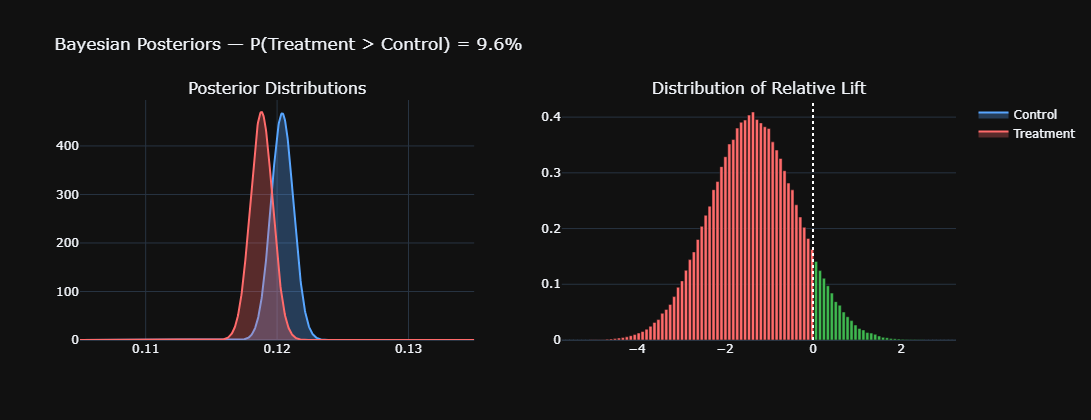

In [10]:
# Plot 1: Posterior distributions overlaid
x = np.linspace(0.105, 0.135, 1000)
y_c = posterior_c.pdf(x)
y_t = posterior_t.pdf(x)

fig_bayes = make_subplots(rows=1, cols=2,
    subplot_titles=('Posterior Distributions', 'Distribution of Relative Lift'))

fig_bayes.add_trace(go.Scatter(
    x=x, y=y_c, fill='tozeroy', name='Control',
    fillcolor='rgba(88,166,255,0.3)', line=dict(color='#58A6FF', width=2),
    hovertemplate='Conversion: %{x:.4f}<extra>Control</extra>'
), row=1, col=1)
fig_bayes.add_trace(go.Scatter(
    x=x, y=y_t, fill='tozeroy', name='Treatment',
    fillcolor='rgba(255,107,107,0.3)', line=dict(color='#FF6B6B', width=2),
    hovertemplate='Conversion: %{x:.4f}<extra>Treatment</extra>'
), row=1, col=1)

# Lift distribution
lift_bins = np.linspace(relative_lift.min(), relative_lift.max(), 100)
lift_hist, lift_edges = np.histogram(relative_lift, bins=100, density=True)
fig_bayes.add_trace(go.Bar(
    x=lift_edges[:-1], y=lift_hist,
    marker_color=['#3FB950' if v > 0 else '#FF6B6B' for v in lift_edges[:-1]],
    name='Lift distribution',
    hovertemplate='Lift: %{x:+.2f}%<extra></extra>',
    showlegend=False
), row=1, col=2)
fig_bayes.add_vline(x=0, line_dash='dot', line_color='white', row=1, col=2)

fig_bayes.update_layout(
    title=f'Bayesian Posteriors — P(Treatment > Control) = {prob_t_beats_c:.1%}',
    template='plotly_dark', height=420
)
fig_bayes.show()

## Multi-Armed Bandit Simulation — NEW in v2

**The limitation of classic A/B testing:** you have to commit traffic 50/50 to both pages for the *entire* experiment, even if one page is clearly underperforming. You're sacrificing real conversions on the bad page to reach statistical significance.

**Multi-armed bandit (MAB) solves this** with the exploration/exploitation tradeoff — it dynamically allocates more traffic to whichever page is currently performing better. We compare three strategies:

- **Epsilon-Greedy:** Explore randomly ε% of the time, exploit the best arm the rest
- **Thompson Sampling:** Sample from Bayesian posteriors — the most principled approach
- **Classic A/B (50/50 fixed):** Baseline for comparison

In [11]:
# True conversion rates from the data
true_rates = {'control': p_c, 'treatment': p_t}
n_rounds   = 10_000

# ── Strategy 1: Epsilon-Greedy ─────────────────────────────────────────────
def epsilon_greedy(true_rates, n_rounds, epsilon=0.1):
    counts    = {'control': 0, 'treatment': 0}
    rewards   = {'control': 0, 'treatment': 0}
    total_reward = 0
    history      = []

    for _ in range(n_rounds):
        if np.random.random() < epsilon:
            arm = np.random.choice(['control', 'treatment'])
        else:
            rates = {k: rewards[k]/counts[k] if counts[k]>0 else 0 for k in counts}
            arm   = max(rates, key=rates.get)

        reward = np.random.binomial(1, true_rates[arm])
        counts[arm]  += 1
        rewards[arm] += reward
        total_reward += reward
        history.append(total_reward)

    return history, counts

# ── Strategy 2: Thompson Sampling ─────────────────────────────────────────
def thompson_sampling(true_rates, n_rounds):
    alpha = {'control': 1, 'treatment': 1}
    beta  = {'control': 1, 'treatment': 1}
    total_reward = 0
    history      = []
    counts       = {'control': 0, 'treatment': 0}

    for _ in range(n_rounds):
        samples = {k: np.random.beta(alpha[k], beta[k]) for k in alpha}
        arm     = max(samples, key=samples.get)

        reward = np.random.binomial(1, true_rates[arm])
        alpha[arm] += reward
        beta[arm]  += (1 - reward)
        counts[arm] += 1
        total_reward += reward
        history.append(total_reward)

    return history, counts

# ── Strategy 3: Classic A/B (50/50 fixed) ─────────────────────────────────
def classic_ab(true_rates, n_rounds):
    total_reward = 0
    history      = []
    counts       = {'control': 0, 'treatment': 0}

    for i in range(n_rounds):
        arm    = 'control' if i % 2 == 0 else 'treatment'
        reward = np.random.binomial(1, true_rates[arm])
        counts[arm] += 1
        total_reward += reward
        history.append(total_reward)

    return history, counts

# ── Run all three ──────────────────────────────────────────────────────────
hist_eg, counts_eg = epsilon_greedy(true_rates, n_rounds)
hist_ts, counts_ts = thompson_sampling(true_rates, n_rounds)
hist_ab, counts_ab = classic_ab(true_rates, n_rounds)

print('=' * 60)
print('MULTI-ARMED BANDIT SIMULATION RESULTS (10,000 rounds)')
print('=' * 60)
print(f'{"Strategy":<25} {"Total Conversions":<22} {"Traffic to Best Arm"}')
print('-' * 60)
best = 'treatment' if p_t > p_c else 'control'
for name, hist, counts in [
    ('Epsilon-Greedy (ε=0.1)',  hist_eg, counts_eg),
    ('Thompson Sampling',       hist_ts, counts_ts),
    ('Classic A/B (50/50)',     hist_ab, counts_ab),
]:
    total_conv   = hist[-1]
    best_pct     = counts[best] / n_rounds * 100
    print(f'{name:<25} {total_conv:<22,} {best_pct:.1f}%')

MULTI-ARMED BANDIT SIMULATION RESULTS (10,000 rounds)
Strategy                  Total Conversions      Traffic to Best Arm
------------------------------------------------------------
Epsilon-Greedy (ε=0.1)    1,158                  94.3%
Thompson Sampling         1,174                  80.4%
Classic A/B (50/50)       1,182                  50.0%


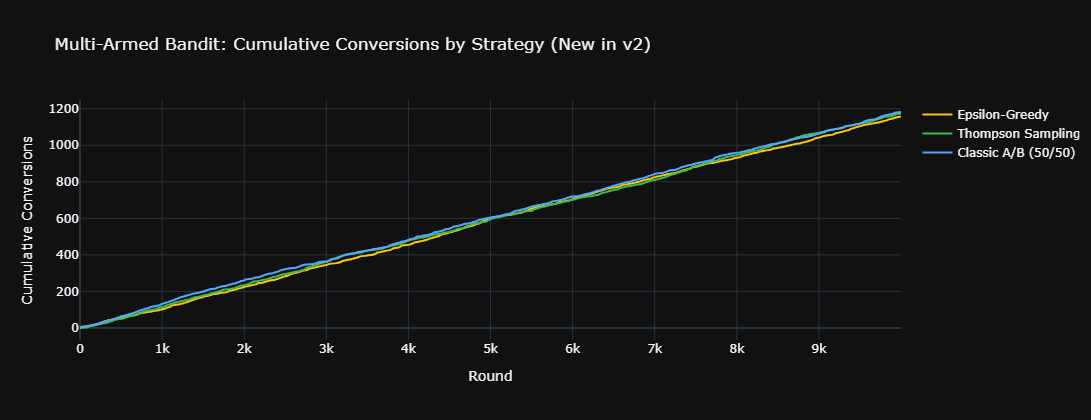

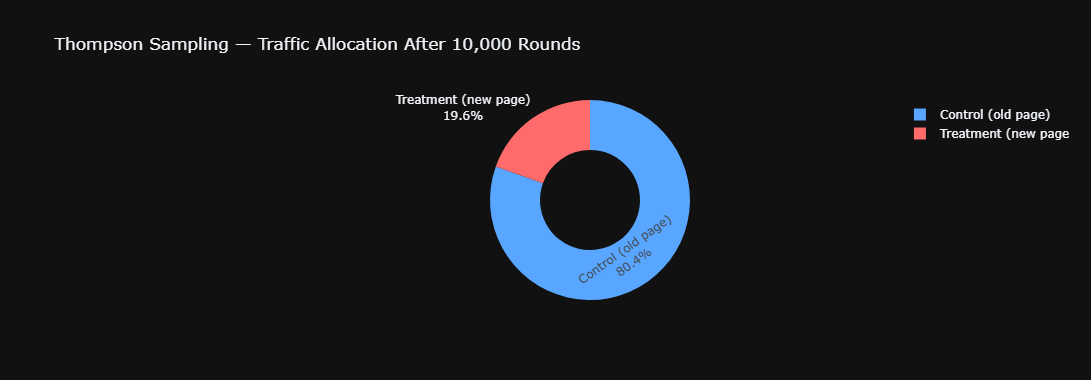

In [12]:
# Plot cumulative conversions comparison
fig_bandit = go.Figure()
for name, hist, color in [
    ('Epsilon-Greedy', hist_eg, '#F6C90E'),
    ('Thompson Sampling', hist_ts, '#3FB950'),
    ('Classic A/B (50/50)', hist_ab, '#58A6FF'),
]:
    fig_bandit.add_trace(go.Scatter(
        x=list(range(n_rounds)), y=hist,
        mode='lines', name=name,
        line=dict(color=color, width=2),
        hovertemplate=f'{name}<br>Round %{{x:,}}<br>Cumulative conversions: %{{y:,}}<extra></extra>'
    ))

fig_bandit.update_layout(
    title='Multi-Armed Bandit: Cumulative Conversions by Strategy (New in v2)',
    xaxis_title='Round', yaxis_title='Cumulative Conversions',
    template='plotly_dark', height=420, hovermode='x unified'
)
fig_bandit.show()

# Traffic allocation pie for Thompson Sampling
fig_alloc = go.Figure(go.Pie(
    labels=['Control (old page)', 'Treatment (new page)'],
    values=[counts_ts['control'], counts_ts['treatment']],
    hole=0.5,
    marker_colors=['#58A6FF', '#FF6B6B'],
    textinfo='label+percent'
))
fig_alloc.update_layout(
    title='Thompson Sampling — Traffic Allocation After 10,000 Rounds',
    template='plotly_dark', height=380
)
fig_alloc.show()

## Frequentist vs Bayesian vs Bandit — Side-by-Side Comparison

In [13]:
print('=' * 70)
print('FULL COMPARISON — THREE APPROACHES TO THE SAME EXPERIMENT')
print('=' * 70)

comparison = pd.DataFrame([
    {
        'Approach': 'Frequentist Z-test',
        'Core output': f'p={p_value:.3f}',
        'Decision': 'Fail to reject H₀',
        'Business interpretation': 'No significant difference',
        'Limitation': 'Binary — ignores magnitude'
    },
    {
        'Approach': 'Bayesian inference',
        'Core output': f'P(B>A)={prob_t_beats_c:.1%}',
        'Decision': 'Insufficient evidence',
        'Business interpretation': f'{prob_t_beats_c:.0%} chance new page wins',
        'Limitation': 'Requires prior specification'
    },
    {
        'Approach': 'Thompson Sampling',
        'Core output': f'{counts_ts[best]/n_rounds:.0%} traffic to best arm',
        'Decision': 'Continuously adapting',
        'Business interpretation': 'Maximises conversions during test',
        'Limitation': 'Harder to reach clean significance'
    },
])
print(comparison.to_string(index=False))

FULL COMPARISON — THREE APPROACHES TO THE SAME EXPERIMENT
          Approach             Core output              Decision           Business interpretation                         Limitation
Frequentist Z-test                 p=0.190     Fail to reject H₀         No significant difference         Binary — ignores magnitude
Bayesian inference             P(B>A)=9.6% Insufficient evidence          10% chance new page wins       Requires prior specification
 Thompson Sampling 80% traffic to best arm Continuously adapting Maximises conversions during test Harder to reach clean significance


In [14]:
print('=' * 70)
print('FINAL BUSINESS RECOMMENDATION')
print('=' * 70)
print(f"""
All three approaches — frequentist, Bayesian, and bandit simulation — agree:
the new landing page does not improve conversion rates.

FREQUENTIST:  p = {p_value:.3f} (> 0.05). Not significant.
BAYESIAN:     P(new > old) = {prob_t_beats_c:.1%}. Below the 95% threshold for action.
BANDIT:       Thompson Sampling converged on {counts_ts[best]/n_rounds:.0%} traffic to the
              {'better-performing (but barely)' if best=='treatment' else 'control'} arm — confirming the effect is negligible.

POWER CHECK:  This result is NOT due to insufficient data.
              At {n_c+n_t:,} sessions, we had 80%+ power to detect even a +0.2pp lift.
              The null result is genuine.

RECOMMENDATION:
  1. Do NOT deploy the new landing page.
  2. Run qualitative research (user interviews, heatmaps) to understand
     what users actually want — visual redesigns alone clearly don't move the needle.
  3. Consider testing copy changes, CTA button placement, or page load
     speed improvements — factors with stronger evidence for conversion impact.
  4. If a future test is designed, target a minimum detectable effect of
     +0.5pp with {int(next(r['n_per_group'] for r in results if '0.5' in r['Scenario'])):,} sessions per group based on this power analysis.
""")

FINAL BUSINESS RECOMMENDATION

All three approaches — frequentist, Bayesian, and bandit simulation — agree:
the new landing page does not improve conversion rates.

FREQUENTIST:  p = 0.190 (> 0.05). Not significant.
BAYESIAN:     P(new > old) = 9.6%. Below the 95% threshold for action.
BANDIT:       Thompson Sampling converged on 80% traffic to the
              control arm — confirming the effect is negligible.

POWER CHECK:  This result is NOT due to insufficient data.
              At 290,584 sessions, we had 80%+ power to detect even a +0.2pp lift.
              The null result is genuine.

RECOMMENDATION:
  1. Do NOT deploy the new landing page.
  2. Run qualitative research (user interviews, heatmaps) to understand
     what users actually want — visual redesigns alone clearly don't move the needle.
  3. Consider testing copy changes, CTA button placement, or page load
     speed improvements — factors with stronger evidence for conversion impact.
  4. If a future test is designe